### 1. 필요한 라이브러리 불러오기

데이터 처리 및 머신러닝 모델 학습에 필요한 라이브러리를 임포트합니다.

In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score
import lightgbm as lgb # LightGBM 라이브러리 임포트
import time # 학습 시간 측정을 위한 time 라이브러리 임포트

print("라이브러리 불러오기 완료.")

라이브러리 불러오기 완료.


### 2. 전처리된 훈련 및 테스트 데이터 로드

`processed_5m` 폴더에서 `train_tabular_ML_opt.parquet`와 `test_tabular_ML_opt.parquet` 파일을 각각 로드합니다. 파일 경로와 이름을 실제 파일에 맞게 수정해주세요.

In [25]:
import os
import zipfile

# ZIP 파일 경로와 압축 해제할 폴더 경로를 설정합니다.
zip_file_path = '/content/processed_5m.zip'
unzip_dir = '/content/processed_5m'

# ZIP 파일이 존재하는지 확인하고 압축을 해제합니다.
if os.path.exists(zip_file_path):
    print(f"{zip_file_path} 파일 압축 해제 중...")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(unzip_dir)
    print(f"'{unzip_dir}' 경로에 파일 압축 해제 완료.")
else:
    print(f"오류: '{zip_file_path}' 파일을 찾을 수 없습니다. ZIP 파일 경로를 확인해주세요.")

# 압축 해제된 폴더 경로를 `folder_path`로 설정합니다.
# 중첩된 폴더 구조를 고려하여 경로를 수정합니다.
folder_path = os.path.join(unzip_dir, 'processed_5m') # 여기를 수정했습니다.

TRAIN_PATH = os.path.join(folder_path, 'train_tabular_ML_opt.parquet')
TEST_PATH = os.path.join(folder_path, 'test_tabular_ML_opt.parquet')

try:
    for path in [TRAIN_PATH, TEST_PATH]:
        if not os.path.exists(path):
            available = [f for f in os.listdir(folder_path) if f.endswith('.parquet')] if os.path.exists(folder_path) else []
            raise FileNotFoundError(
                f"오류: '{path}' 파일을 찾을 수 없습니다. '{folder_path}' 폴더의 parquet 파일: {available}"
            )

    train_df = pd.read_parquet(TRAIN_PATH)
    test_df = pd.read_parquet(TEST_PATH)

    print("데이터 로드 완료.")
    print('Train 크기:', train_df.shape)
    print('Test 크기:', test_df.shape)

    print('\n컬럼 목록:')
    print(train_df.columns.tolist())

    print('\nTrain 데이터 확인:')
    display(train_df.head())

    print('\nTest 데이터 확인:')
    display(test_df.head())

except FileNotFoundError as e:
    print(e)
    print(f"예시: folder_path = '/content/drive/MyDrive/my_data/{os.path.basename(unzip_dir)}' 또는 ZIP 파일명 확인.")
except Exception as e:
    print(f"데이터 로드 중 오류가 발생했습니다: {e}")

/content/processed_5m.zip 파일 압축 해제 중...
'/content/processed_5m' 경로에 파일 압축 해제 완료.
데이터 로드 완료.
Train 크기: (109378, 12)
Test 크기: (109736, 12)

컬럼 목록:
['recency_days', 'tenure_days', 'ndays', 'n_events', 'n_view', 'n_cart', 'n_remove_from_cart', 'n_purchase', 'avg_price', 'purch_amt', 'churn', 'user_id']

Train 데이터 확인:


,recency_days,tenure_days,ndays,n_events,n_view,n_cart,n_remove_from_cart,n_purchase,avg_price,purch_amt,churn,user_id
0,0.744742,0.000000,0.000000,0.000000,0.070130,0.000000,0.000000,0.000000,0.021783,0.000000,1,9582366
1,0.539424,0.066815,0.230787,0.335133,0.340690,0.322270,0.214858,0.000000,0.019697,0.000000,0,12961898
2,0.208004,0.000036,0.000000,0.238987,0.297907,0.000000,0.000000,0.000000,0.024063,0.000000,1,16460232
3,0.326894,0.000007,0.000000,0.043042,0.000000,0.134158,0.000000,0.000000,0.015300,0.000000,1,17130461
4,0.324472,0.967386,0.592242,0.602799,0.605432,0.532022,0.558078,0.343591,0.016679,0.388262,1,20554973



Test 데이터 확인:


,recency_days,tenure_days,ndays,n_events,n_view,n_cart,n_remove_from_cart,n_purchase,avg_price,purch_amt,churn,user_id
0,0.777817,0.000000,0.000000,0.000000,0.07013,0.000000,0.000000,0.0,0.077430,0.0,1,2038666
1,0.114182,0.000000,0.000000,0.000000,0.07013,0.000000,0.000000,0.0,0.048905,0.0,1,4230352
2,0.525558,0.025882,0.174583,0.220744,0.27399,0.000000,0.083119,0.0,0.021734,0.0,1,4661182
3,0.303018,0.000000,0.000000,0.000000,0.00000,0.084644,0.000000,0.0,0.017329,0.0,1,6217356
4,0.796228,0.000000,0.000000,0.073581,0.00000,0.169288,0.000000,0.0,0.007566,0.0,1,9794320


### 3. 훈련 및 테스트 데이터에서 특성과 타겟 분리

훈련 데이터(`train_df`)와 테스트 데이터(`test_df`) 각각에서 예측에 사용할 특성(X)과 예측하고자 하는 타겟(y)을 분리합니다. `target` 컬럼 이름을 실제 타겟 컬럼 이름으로 변경해야 합니다.

In [26]:
if 'train_df' in locals() and not train_df.empty and 'test_df' in locals() and not test_df.empty:
    # 타겟 컬럼 이름을 실제 타겟 컬럼 이름으로 변경해주세요.
    # 현재 데이터프레임 컬럼 목록에 'churn'이 있으므로, 'churn'으로 설정합니다.
    TARGET_COLUMN = 'churn'

    if TARGET_COLUMN in train_df.columns and TARGET_COLUMN in test_df.columns:
        X_train = train_df.drop(columns=[TARGET_COLUMN, 'user_id']) # 'user_id'는 특성에서 제외할 수 있습니다.
        y_train = train_df[TARGET_COLUMN]

        X_test = test_df.drop(columns=[TARGET_COLUMN, 'user_id']) # 'user_id'는 특성에서 제외할 수 있습니다.
        y_test = test_df[TARGET_COLUMN]

        print(f"훈련 특성(X_train)과 타겟(y_train) 분리 완료. X_train.shape: {X_train.shape}, y_train.shape: {y_train.shape}")
        print(f"테스트 특성(X_test)과 타겟(y_test) 분리 완료. X_test.shape: {X_test.shape}, y_test.shape: {y_test.shape}")
    else:
        print(f"오류: 타겟 컬럼 '{TARGET_COLUMN}'을(를) 훈련 또는 테스트 데이터에서 찾을 수 없습니다. 컬럼 이름을 확인해주세요.")
else:
    print("오류: 훈련 또는 테스트 데이터프레임이 로드되지 않았거나 비어있습니다. 이전 단계를 확인해주세요.")

훈련 특성(X_train)과 타겟(y_train) 분리 완료. X_train.shape: (109378, 10), y_train.shape: (109378,)
테스트 특성(X_test)과 타겟(y_test) 분리 완료. X_test.shape: (109736, 10), y_test.shape: (109736,)


### 4. 훈련 데이터에서 검증 세트 분리

모델 개발 단계에서의 성능 평가를 위해 기존 `X_train`, `y_train` 데이터를 훈련 세트와 검증 세트(`X_val`, `y_val`)로 추가 분리합니다. 최종 테스트 데이터(`X_test`, `y_test`)는 별도로 유지됩니다.

In [27]:
# X_train과 y_train을 다시 훈련 세트와 검증 세트로 분리합니다.
# 여기서는 훈련 데이터의 25%를 검증 세트로 사용합니다.
X_train_split, X_val, y_train_split, y_val = train_test_split(X_train, y_train, test_size=0.05, random_state=42, stratify=y_train)

print(f"새로운 훈련 세트: {X_train_split.shape}, 검증 세트: {X_val.shape}")

새로운 훈련 세트: (103909, 10), 검증 세트: (5469, 10)


### 5.1. RandomForest 모델 훈련 (훈련 세트)

RandomForestClassifier 모델을 초기화하고 분리된 훈련 세트(`X_train_split`, `y_train_split`)로 학습시킵니다.

In [36]:
if 'X_train_split' in locals() and 'y_train_split' in locals():
    # RandomForestClassifier를 사용합니다. 회귀 문제라면 RandomForestRegressor를 사용하세요.
    # 모델의 하이퍼파라미터는 필요에 따라 조정할 수 있습니다.
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

    start_time = time.time() # 학습 시작 시간 기록
    model.fit(X_train_split, y_train_split) # 분리된 훈련 세트로 학습
    end_time = time.time() # 학습 종료 시간 기록
    rf_train_time_sec = end_time - start_time # 학습 시간 계산

    print("RandomForest 모델 훈련 완료.")
    print(f"RandomForest 모델 학습 시간: {rf_train_time_sec:.2f} 초")
else:
    print("오류: 새로운 훈련 데이터가 준비되지 않았습니다. 이전 단계를 확인해주세요.")

RandomForest 모델 훈련 완료.
RandomForest 모델 학습 시간: 26.61 초


### 5.2. RandomForest 모델 성능 평가 (검증 세트)

훈련된 RandomForest 모델의 성능을 평가합니다. accuracy, precision, recall, F1-score, ROC AUC, PR AUC, 혼동 행렬을 출력합니다.


--- RandomForest 모델 성능 평가 (검증 세트) ---
RandomForest 모델 정확도 (Accuracy): 0.8429

Classification Report (정밀도, 재현율, F1-Score):
              precision    recall  f1-score   support

           0       0.61      0.33      0.43       975
           1       0.87      0.95      0.91      4494

    accuracy                           0.84      5469
   macro avg       0.74      0.64      0.67      5469
weighted avg       0.82      0.84      0.82      5469

ROC AUC: 0.7802
PR AUC: 0.9345

Confusion Matrix (혼동 행렬):


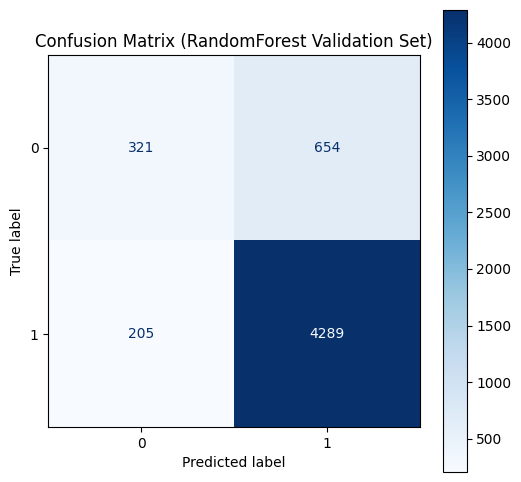

In [32]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

if 'model' in locals() and 'X_val' in locals() and 'y_val' in locals():
    y_pred = model.predict(X_val)

    print("\n--- RandomForest 모델 성능 평가 (검증 세트) ---")

    # 1. 정확도 (Accuracy)
    accuracy = accuracy_score(y_val, y_pred)
    print(f"RandomForest 모델 정확도 (Accuracy): {accuracy:.4f}")

    # 2. 정밀도, 재현율, F1-Score (Classification Report)
    print("\nClassification Report (정밀도, 재현율, F1-Score):")
    print(classification_report(y_val, y_pred))

    # 확률 예측 (ROC AUC와 PR AUC 계산에 필요)
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_val) # X_val로 예측
        # 이진 분류를 가정하고 양성 클래스(1)의 확률을 사용합니다.
        if y_proba.shape[1] == 2:
            y_proba_positive = y_proba[:, 1]

            # 3. ROC AUC
            try:
                roc_auc = roc_auc_score(y_val, y_proba_positive)
                print(f"ROC AUC: {roc_auc:.4f}")
            except ValueError:
                print("ROC AUC를 계산할 수 없습니다. 타겟 클래스 분포를 확인하세요.")

            # 4. PR AUC
            precision, recall, _ = precision_recall_curve(y_val, y_proba_positive)
            pr_auc = auc(recall, precision)
            print(f"PR AUC: {pr_auc:.4f}")
        else:
            print("predict_proba가 다중 클래스 예측을 반환합니다. ROC AUC와 PR AUC는 이진 분류에 일반적으로 사용됩니다.")
    else:
        print("모델이 확률 예측(predict_proba)을 지원하지 않습니다. ROC AUC와 PR AUC를 계산할 수 없습니다.")

    # 5. 혼동 행렬 (Confusion Matrix)
    print("\nConfusion Matrix (혼동 행렬):")
    fig, ax = plt.subplots(figsize=(6, 6))
    cm_display = ConfusionMatrixDisplay.from_estimator(model, X_val, y_val, cmap=plt.cm.Blues, ax=ax) # X_val, y_val로 혼동 행렬 생성
    plt.title('Confusion Matrix (RandomForest Validation Set)') # 제목 변경
    plt.show()

else:
    print("오류: 모델 또는 검증 데이터가 준비되지 않았습니다. 이전 단계를 확인해주세요.")

### 5.3. LightGBM 모델 훈련 (훈련 세트)

이전에 훈련한 RandomForest 모델과 별개로 LightGBM 모델을 학습하여 성능을 비교합니다. `X_train_split`과 `y_train_split`으로 모델을 훈련합니다.

In [37]:
if 'X_train_split' in locals() and 'y_train_split' in locals():
    # LightGBM Classifier를 사용합니다.
    # 모델의 하이퍼파라미터는 필요에 따라 조정할 수 있습니다.
    lgbm_model = lgb.LGBMClassifier(objective='binary', random_state=42, n_jobs=-1)

    start_time_lgbm = time.time() # 학습 시작 시간 기록
    lgbm_model.fit(X_train_split, y_train_split) # 분리된 훈련 세트로 학습
    end_time_lgbm = time.time() # 학습 종료 시간 기록
    lgbm_train_time_sec = end_time_lgbm - start_time_lgbm # 학습 시간 계산

    print("LightGBM 모델 훈련 완료.")
    print(f"LightGBM 모델 학습 시간: {lgbm_train_time_sec:.2f} 초")
else:
    print("오류: 새로운 훈련 데이터가 준비되지 않았습니다. 이전 단계를 확인해주세요.")

[LightGBM] [Info] Number of positive: 85385, number of negative: 18524
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.046898 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2272
[LightGBM] [Info] Number of data points in the train set: 103909, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.821729 -> initscore=1.528103
[LightGBM] [Info] Start training from score 1.528103
LightGBM 모델 훈련 완료.
LightGBM 모델 학습 시간: 2.18 초


### 5.4. LightGBM 모델 성능 평가 (검증 세트)

훈련된 LightGBM 모델의 성능을 검증 세트(`X_val`, `y_val`)에서 평가합니다. accuracy, precision, recall, F1-score, ROC AUC, PR AUC, 혼동 행렬을 출력합니다.


--- LightGBM 모델 성능 평가 (검증 세트) ---
LightGBM 모델 정확도 (Accuracy): 0.8493

Classification Report (정밀도, 재현율, F1-Score):
              precision    recall  f1-score   support

           0       0.68      0.29      0.40       975
           1       0.86      0.97      0.91      4494

    accuracy                           0.85      5469
   macro avg       0.77      0.63      0.66      5469
weighted avg       0.83      0.85      0.82      5469

ROC AUC: 0.8084
PR AUC: 0.9400

Confusion Matrix (혼동 행렬):


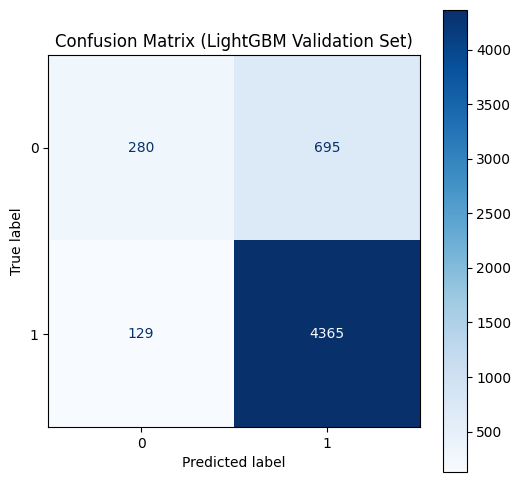

In [34]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

if 'lgbm_model' in locals() and 'X_val' in locals() and 'y_val' in locals():
    y_pred_lgbm = lgbm_model.predict(X_val)

    print("\n--- LightGBM 모델 성능 평가 (검증 세트) ---")

    # 1. 정확도 (Accuracy)
    accuracy_lgbm = accuracy_score(y_val, y_pred_lgbm)
    print(f"LightGBM 모델 정확도 (Accuracy): {accuracy_lgbm:.4f}")

    # 2. 정밀도, 재현율, F1-Score (Classification Report)
    print("\nClassification Report (정밀도, 재현율, F1-Score):")
    print(classification_report(y_val, y_pred_lgbm))

    # 확률 예측 (ROC AUC와 PR AUC 계산에 필요)
    if hasattr(lgbm_model, 'predict_proba'):
        y_proba_lgbm = lgbm_model.predict_proba(X_val)
        # 이진 분류를 가정하고 양성 클래스(1)의 확률을 사용합니다.
        if y_proba_lgbm.shape[1] == 2:
            y_proba_positive_lgbm = y_proba_lgbm[:, 1]

            # 3. ROC AUC
            try:
                roc_auc_lgbm = roc_auc_score(y_val, y_proba_positive_lgbm)
                print(f"ROC AUC: {roc_auc_lgbm:.4f}")
            except ValueError:
                print("ROC AUC를 계산할 수 없습니다. 타겟 클래스 분포를 확인하세요.")

            # 4. PR AUC
            precision_lgbm, recall_lgbm, _ = precision_recall_curve(y_val, y_proba_positive_lgbm)
            pr_auc_lgbm = auc(recall_lgbm, precision_lgbm)
            print(f"PR AUC: {pr_auc_lgbm:.4f}")
        else:
            print("predict_proba가 다중 클래스 예측을 반환합니다. ROC AUC와 PR AUC는 이진 분류에 일반적으로 사용됩니다.")
    else:
        print("모델이 확률 예측(predict_proba)을 지원하지 않습니다. ROC AUC와 PR AUC를 계산할 수 없습니다.")

    # 5. 혼동 행렬 (Confusion Matrix)
    print("\nConfusion Matrix (혼동 행렬):")
    fig, ax = plt.subplots(figsize=(6, 6))
    cm_display_lgbm = ConfusionMatrixDisplay.from_estimator(lgbm_model, X_val, y_val, cmap=plt.cm.Blues, ax=ax)
    plt.title('Confusion Matrix (LightGBM Validation Set)')
    plt.show()

else:
    print("오류: LightGBM 모델 또는 검증 데이터가 준비되지 않았습니다. 이전 단계를 확인해주세요.")

### 5.5. 두 모델 성능 비교

RandomForest와 LightGBM 두 모델의 검증 세트 성능 지표와 학습 시간을 종합하여 비교표를 생성합니다.

In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score

# RandomForest 모델의 지표 추출
rf_accuracy = accuracy_score(y_val, y_pred)
rf_precision = precision_score(y_val, y_pred)
rf_recall = recall_score(y_val, y_pred)
rf_f1 = f1_score(y_val, y_pred)
rf_roc_auc = roc_auc_score(y_val, y_proba_positive)
rf_pr_auc = auc(recall, precision) # precision, recall은 RandomForest 평가 시 계산된 값

# LightGBM 모델의 지표 추출
lgbm_accuracy = accuracy_score(y_val, y_pred_lgbm)
lgbm_precision = precision_score(y_val, y_pred_lgbm)
lgbm_recall = recall_score(y_val, y_pred_lgbm)
lgbm_f1 = f1_score(y_val, y_pred_lgbm)
lgbm_roc_auc = roc_auc_score(y_val, y_proba_positive_lgbm)
lgbm_pr_auc = auc(recall_lgbm, precision_lgbm) # precision_lgbm, recall_lgbm은 LightGBM 평가 시 계산된 값

# 결과 DataFrame 생성
results_df = pd.DataFrame({
    'model': ['RandomForest', 'LightGBM'],
    'accuracy': [rf_accuracy, lgbm_accuracy],
    'precision': [rf_precision, lgbm_precision],
    'recall': [rf_recall, lgbm_recall],
    'f1': [rf_f1, lgbm_f1],
    'roc_auc': [rf_roc_auc, lgbm_roc_auc],
    'pr_auc': [rf_pr_auc, lgbm_pr_auc],
    'train_time_sec': [rf_train_time_sec, lgbm_train_time_sec]
})

print("\n--- 모델 성능 비교 (검증 세트) ---")
display(results_df.round(4))


--- 모델 성능 비교 (검증 세트) ---


,model,accuracy,precision,recall,f1,roc_auc,pr_auc,train_time_sec
0,RandomForest,0.8429,0.8677,0.9544,0.9090,0.7802,0.9345,26.6090
1,LightGBM,0.8493,0.8626,0.9713,0.9138,0.8084,0.9400,2.1751
